In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive (5).zip"  # Your mounted Drive file path

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")  # Extract into Colab local disk

print("✅ Extracted files:", os.listdir("/content/data"))

✅ Extracted files: ['images', 'indiana_projections.csv', 'indiana_reports.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("data/indiana_reports.csv")
print("✅ Loaded:", df.shape)

✅ Loaded: (3851, 8)


# step1: load data + Preprocessing


- **Text Cleaning**:
  - Fill missing values in `impression`, `findings`, `indication`, and `comparison` fields with placeholders like "No impression".
  - Define a cleaning function to:
    - Remove HTML tags.
    - Expand English contractions (e.g., won't → will not).
    - Remove bullet numbers, placeholders (XXXXX), and URLs.
    - Remove non-letter characters (keep periods for sentence separation).
    - Normalize spaces and lowercase all text.
  - Apply the cleaning function to all four text fields.

- **Create Captions**:
  - Concatenate `impression` and `findings` for each report.
  - Remove redundant (duplicate) sentences in the concatenated text.
  - Save the result in a new column `caption`.

- **Word Cloud Visualization**:
  - Generate and display word clouds for:
    - `indication` field.
    - `findings` field.
    - Combined `caption` field.
  - Helps visualize the most frequent words in each text field.

- **Match Image Files**:
  - Match each report's `uid` to its corresponding image file in the `images_normalized` folder.
  - The image filename must start with the UID and end with `.dcm.png`.
  - Save the matched image path to a new column `image_path`.

- **Save Final Dataset**:
  - Filter the dataset to keep only rows where a matching image was found.
  - Save a new CSV file `data.csv` containing:
    - `image_path`: Path to the corresponding X-ray image.
    - `caption`: Cleaned and merged report text.



Cleaning Text: 100%|██████████| 3851/3851 [00:00<00:00, 6611.54it/s]


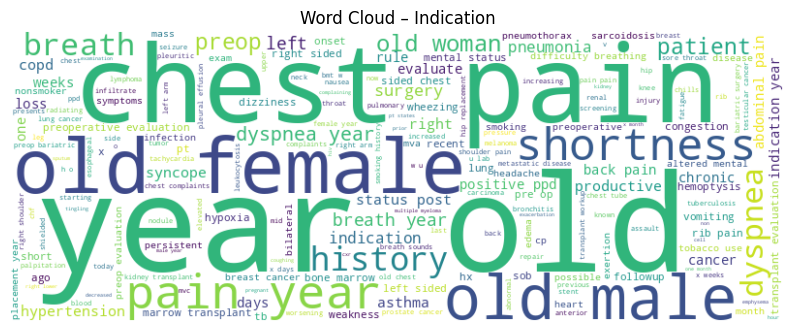

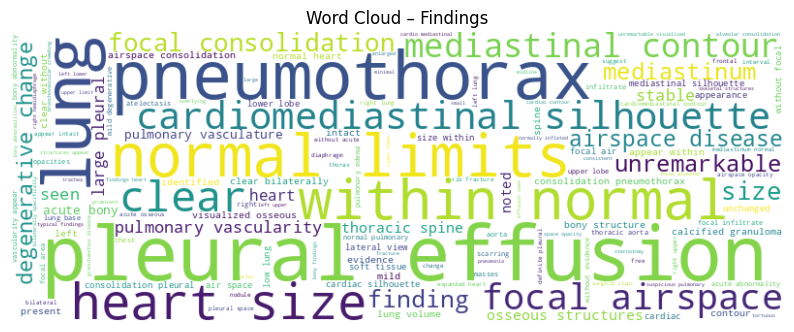

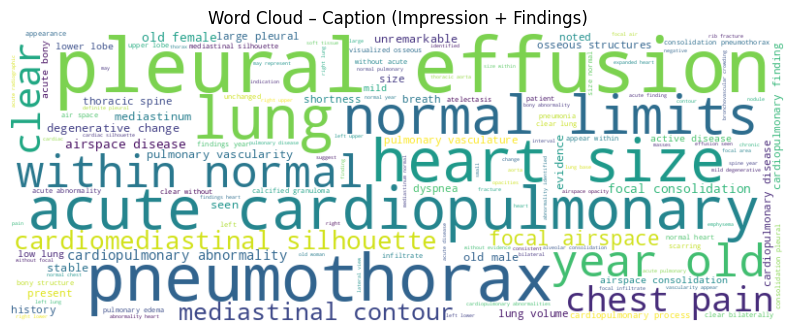

✅ Final data saved: 3851 image-caption pairs


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from bs4 import BeautifulSoup
from tqdm import tqdm
import numpy as np
import re


# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("data/indiana_reports.csv")


# -----------------------------
# Text Cleaning
# -----------------------------

# Fill Missing Text
df["impression"] = df["impression"].fillna("No impression")
df["findings"] = df["findings"].fillna("No findings")
df["indication"] = df["indication"].fillna("No indication")
df["comparison"] = df["comparison"].fillna("No comparison")

# Cleaning function
def decontracted(phrase):
    phrase = re.sub(r"won\'t", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'s", " is", phrase)
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)
    return phrase

def clean_text_column(text_series):
    cleaned = []
    for text in tqdm(text_series.fillna(""), desc="Cleaning Text"):
        text = BeautifulSoup(text, 'lxml').get_text() # Remove HTML tags
        text = decontracted(text)                 # Expand contractions
        text = re.sub(r"\d+\.", "", text)         # remove bullet numbers like 1. 2.
        text = re.sub(r"X+", "", text)            # Remove placeholders like XXXXX
        text = re.sub(r"http\S+", "", text)       # remove URLs
        text = re.sub(r"[^a-zA-Z. ]", " ", text)  # remove non-letter chars (keep dots)
        text = re.sub(r"\s+", " ", text)          # normalize spaces
        text = text.lower().strip()               # # Lowercase and remove extra spaces
        cleaned.append(text if text else np.nan)
    return cleaned

#Apply Text Cleaning
df["impression"] = clean_text_column(df["impression"])
df["findings"] = clean_text_column(df["findings"])
df["indication"] = clean_text_column(df["indication"])
df["comparison"] = clean_text_column(df["comparison"])

# -----------------------------
# Create Captions (Impression + Findings)
# -----------------------------

def remove_redundancy(text):
    # Split on any period followed by optional whitespace
    sentences = re.split(r'\.\s*', text)
    # Clean and filter empty parts
    sentences = [s.strip() for s in sentences if s.strip()]
    # Remove exact duplicates while preserving order
    unique_sentences = list(dict.fromkeys(sentences))
    # Rejoin with ". " and add final period
    return '. '.join(unique_sentences) + '.'

df["caption"] = (
    df["indication"].fillna('') + ". " +
    df["impression"].fillna('') + ". " +
    df["findings"].fillna('')
).apply(remove_redundancy)



# -----------------------------
# Word Clouds
# -----------------------------
text_indication = " ".join(df["indication"].dropna())
wordcloud_ind = WordCloud(width=800, height=300, background_color="white").generate(text_indication)
plt.figure(figsize=(10, 4))
plt.imshow(wordcloud_ind, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Indication")
plt.show()

text_findings = " ".join(df["findings"].dropna())
wordcloud_find = WordCloud(width=800, height=300, background_color="white").generate(text_findings)
plt.figure(figsize=(10, 4))
plt.imshow(wordcloud_find, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Findings")
plt.show()

# New Word Cloud for Caption
text_caption = " ".join(df["caption"].dropna())
wordcloud_caption = WordCloud(width=800, height=300, background_color="white").generate(text_caption)
plt.figure(figsize=(10, 4))
plt.imshow(wordcloud_caption, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Caption (Impression + Findings)")
plt.show()


# -----------------------------------------------
# Match Image Files and save the data set
# -----------------------------------------------

# This block links each X-ray report to its image file and saves a clean dataset of image-caption pairs in data.csv.
image_folder = "data/images/images_normalized"
available_files = set(os.listdir(image_folder)) #ists all filenames in the folder
                                                #Convert to set:For fast lookup — checking membership in a set is
                                                  #O(1) vs O(n) for a list

def match_uid_to_filename(uid):
    prefix = str(uid)
    for fname in available_files:
        if fname.startswith(prefix) and fname.endswith(".dcm.png"):
            return os.path.join(image_folder, fname)
    return None

df["image_path"] = df["uid"].apply(match_uid_to_filename)


# Save
df_filtered = df[df["image_path"].notnull()]
df_filtered[["image_path", "caption"]].to_csv("data.csv", index=False)
print(f"✅ Final data saved: {len(df_filtered)} image-caption pairs")



# Step 2: Visual Feature Extraction
### 🔍 Feature Extraction and Fusion (Model 3: ViT + DenseNet121 + Handcrafted)

This code performs complete feature extraction and fusion for **Model 3**, which combines:
- **ViT [CLS] embeddings** (768-dim)
- **DenseNet121 global features** (1024-dim)
- **Handcrafted features** (76, including edge, brightness, texture, and statistical metrics)

#### 📌 Steps:

1. **Device Setup**:
   Automatically uses GPU if available.

2. **Model Loading**:
   - `ViTModel` pretrained on ImageNet-21k
   - `DenseNet121` pretrained on CheXpert via `torchxrayvision`

3. **Dataset Preparation**:
   - Loads images and captions from `data.csv`
   - Preprocesses RGB images for ViT
   - Converts grayscale images for DenseNet121
   - Keeps image paths for handcrafted extraction

4. **Handcrafted Feature Extraction**:
   Extracts interpretable features including:
   - Sobel edge strength
   - Brightness mean
   - GLCM texture metrics (contrast, energy, etc.)
   - LBP histogram
   - Histogram statistics (mean, std, skewness, entropy)
   - Canny edge density
   - Laplacian sharpness
   - Brightness range

5. **Batch Feature Extraction**:
   For each batch:
   - Extracts ViT [CLS] tokens
   - Extracts DenseNet features via global average pooling
   - Computes handcrafted features per image

6. **Normalization and Fusion**:
   - Handcrafted features are normalized using `StandardScaler`
   - All three types are concatenated into a single fused feature vector of size `1872`
     ```
     [ViT (768)] + [DenseNet121 (1024)] + [Handcrafted (~80)]
     ```

7. **Final Output**:
   - `fused_features`: Tensor of shape `[num_images, 1872]`
   - Ready for projection into GPT-2 hidden size and passed as `encoder_hidden_states` for report generation

> ✅ This is the input representation for **Model 3: Full Fusion (ViT + DenseNet121 + Handcrafted)**.


In [ ]:
!pip install git+https://github.com/mlmed/torchxrayvision --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.5 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTModel, AutoImageProcessor
from sklearn.preprocessing import StandardScaler
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.stats import skew, kurtosis
import torchxrayvision as xrv

# ==============================
# Device Setup
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==============================
# Load Models
# ==============================
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k").to(device)
vit_model.eval()
vit_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

densenet_model = xrv.models.DenseNet(weights="densenet121-res224-chex").to(device)
densenet_model.eval()

# ==============================
# Load Dataset
# ==============================
df = pd.read_csv("data.csv")

# ==============================
# Dataset Class
# ==============================
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, vit_processor):
        self.data = dataframe.reset_index(drop=True)
        self.vit_processor = vit_processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row['image_path']
        caption = row['caption']
        image_rgb = Image.open(image_path).convert("RGB")
        image_gray = Image.open(image_path).convert("L")

        # ViT preprocessing
        vit_inputs = self.vit_processor(images=image_rgb, return_tensors="pt")
        vit_inputs = {k: v.squeeze(0) for k, v in vit_inputs.items()}

        # DenseNet preprocessing
        image_gray_np = np.array(image_gray) / 255.0
        image_gray_np = cv2.resize(image_gray_np, (224, 224))
        image_gray_tensor = torch.tensor(image_gray_np).unsqueeze(0).float()  # [1, 224, 224]

        return {
            "pixel_values": vit_inputs["pixel_values"],   # for ViT
            "densenet_image": image_gray_tensor,          # for DenseNet
            "image_path": image_path,                     # for handcrafted
            "caption": caption
        }

# ==============================
# Handcrafted Feature Function
# ==============================
def extract_handcrafted_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224))
    feats = []

    # Sobel Edge Strength
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    edge_strength = np.mean(np.hypot(sobelx, sobely))
    feats.append(edge_strength)

    # Brightness Mean
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    brightness_mean = np.mean(hist)
    feats.append(brightness_mean)

    # GLCM Texture
    glcm_matrix = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    for prop in ['contrast', 'correlation', 'energy', 'homogeneity', 'dissimilarity']:
        feats.append(graycoprops(glcm_matrix, prop)[0, 0])

    # LBP
    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 59 + 3), range=(0, 59 + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    feats.extend(hist.tolist())

    # Histogram Stats
    hist_values = img.flatten()
    feats.extend([
        np.mean(hist_values),
        np.std(hist_values),
        skew(hist_values),
        kurtosis(hist_values),
        -np.sum((hist_values / 255.0) * np.log2((hist_values / 255.0) + 1e-7))
    ])

    # Canny Edge Density
    edges = cv2.Canny(img, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    feats.append(edge_density)

    # Laplacian Variance (Sharpness)
    lap_var = cv2.Laplacian(img, cv2.CV_64F).var()
    feats.append(lap_var)

    # Brightness Range
    brightness_range = np.max(img) - np.min(img)
    feats.append(brightness_range)

    return np.array(feats, dtype=np.float32)

# ==============================
# Dataloader
# ==============================
dataset = ChestXrayDataset(df, vit_processor)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

# ==============================
# Feature Extraction Loop
# ==============================
vit_features = []
densenet_features = []
handcrafted_features = []

with torch.no_grad():
    for batch in dataloader:
        # ViT features
        vit_out = vit_model(pixel_values=batch["pixel_values"].to(device))
        cls_tokens = vit_out.last_hidden_state[:, 0, :]  # [B, 768]
        vit_features.append(cls_tokens.cpu())

        # DenseNet features
        dn_input = batch["densenet_image"].to(device)  # [B, 1, 224, 224]
        dn_out = densenet_model.features(dn_input)
        dn_out = torch.nn.functional.adaptive_avg_pool2d(dn_out, (1, 1))
        dn_flat = dn_out.view(dn_out.size(0), -1)  # [B, 1024]
        densenet_features.append(dn_flat.cpu())

        # Handcrafted features
        for path in batch["image_path"]:
            handcrafted = extract_handcrafted_features(path)
            handcrafted_features.append(handcrafted)

# ==============================
# Stack + Normalize
# ==============================
vit_features = torch.cat(vit_features, dim=0)  # [N, 768]
densenet_features = torch.cat(densenet_features, dim=0)  # [N, 1024]
handcrafted_features = np.stack(handcrafted_features, axis=0)  # [N, 76]
handcrafted_features = StandardScaler().fit_transform(handcrafted_features)
handcrafted_features = torch.tensor(handcrafted_features, dtype=torch.float32)

# ==============================
# Final Fusion
# ==============================
image_features  = torch.cat([vit_features, densenet_features, handcrafted_features], dim=1)  # [N, 1872]
print("✅ Final Fused Feature Shape:", image_features.shape)


Using device: cuda


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/chex-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/chex-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]
✅ Final Fused Feature Shape: torch.Size([3851, 1868])


# Step 3: GPT-2 Decoder with Cross-Attention

### 🧠 Full Flow of Step 3: Report Generation Pipeline

1. **Load Pretrained GPT-2 Model with Cross-Attention**
   - Load GPT-2 (small version) with cross-attention enabled.
   - Set `pad_token_id` for proper padding handling.
  
2. **Prepare Dataset**
   - **Project image features** from 770D → 768D.
   - Define a **custom PyTorch Dataset**:
     - Returns tokenized captions (`input_ids`), attention masks, and projected image features.
   - Create a **DataLoader** for batching.

3. **Training Loop**
   - **Split dataset** into train/validation/test (70/15/15).
   - **Training**:
     - Forward pass: feed tokenized captions.
     - Use image features as cross-attention context.
     - Compute language modeling loss.
     - Backpropagate and update model parameters.
   - **Validation**:
     - Same forward pass, but no gradients.
     - Compute validation loss and perplexity.
   - **Plot** training and validation loss/perplexity curves.

4. **Inference / Report Generation**
   - Set model to **evaluation** mode.
   - Loop over **test dataset**:
     - Pass image features to GPT-2 as cross-attention context.
     - Generate a caption using **beam search**.
     - Decode generated token IDs into text.
     - Decode ground-truth captions for comparison.
   - Save results (image path, reference caption, generated caption) into `generated_reports.csv`.

✅ **Outcome**:
> A trained GPT-2 model capable of generating chest X-ray medical reports conditioned on image features.



                           +--------------------------+
                           |    Pretrained ViT + Hand   |
                           |  Image Features (770-D)    |
                           +-------------+-------------+
                                         |
                                         v
                       +-------------------------------+
                       |  Projection Layer (770 → 768)  |
                       +-------------+-----------------+
                                         |
                                         v
                           +--------------------------+
                           |     GPT-2 (w/ Cross-Attn)  |
                           +-------------+-------------+
                                         |
              +--------------------------+--------------------------+
              |                                                     |
    +---------v---------+                                 +---------v---------+
    |  Training Phase    |                                 |  Inference Phase   |
    +--------------------+                                +--------------------+
    |  - Tokenize captions|                                |  - Generate report |
    |  - Feed input_ids    |                               |  - Beam Search     |
    |  - Feed attention_mask|                              |  - Decode captions |
    |  - Feed image_feature|                               |                    |
    |  - Compute Loss     |                                |                    |
    +--------------------+                                +--------------------+
              |                                                     |
              v                                                     v
     +-----------------+                               +------------------------------+
     |  Training Loss &  |                              | Save to `generated_reports.csv`|
     | Perplexity Curves |                              +------------------------------+
     +------------------+


In [ ]:
# === Step 3.1 — Load GPT-2 Model with Cross-Attention Enabled + Projection ===

from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch.nn as nn

#image_features = fused_features
# Specify small GPT-2 variant
gpt2_name = "gpt2"   # Use 'gpt2' — small size (~124M parameters)

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(gpt2_name)   # Load GPT-2 tokenizer
tokenizer.pad_token = tokenizer.eos_token              # GPT-2 does not have a built-in padding token —
                                                       # so we set the pad token to be the end-of-sentence token (EOS token).


# Load GPT-2 model with cross-attention enabled
'''
Adds cross-attention layers between the language model and the image features.
Why cross-attention?
This allows the decoder (GPT-2) to attend to external inputs — in your case, the image features — while generating the report.
'''
model = GPT2LMHeadModel.from_pretrained(gpt2_name, add_cross_attention=True)  # Load GPT-2 with cross-attention
model.config.pad_token_id = model.config.eos_token_id    # Set pad_token_id in config for masking during loss calculation
                                                         #Padding tokens will not affect loss calculation.
model = model.to(device)
model.train()

# === Projection Layer for Image Features ===
# Extract feature dimensions
image_feat_dim = image_features.shape[1]     # 770 — from previous step (ViT [CLS] + handcrafted features)
gpt2_hidden_size = model.config.hidden_size  # 768 — GPT-2 hidden size

# Add a projection layer to match image features to GPT-2 hidden size
projector = nn.Linear(image_feat_dim, gpt2_hidden_size).to(device)  # Linear layer: 770 → 768

# Confirm everything is loaded correctly
print(f"✅ GPT-2 loaded with cross-attention. Projecting image features from {image_feat_dim} → {gpt2_hidden_size}.")




tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['transformer.h.0.crossattention.c_attn.bias', 'transformer.h.0.crossattention.c_attn.weight', 'transformer.h.0.crossattention.c_proj.bias', 'transformer.h.0.crossattention.c_proj.weight', 'transformer.h.0.crossattention.q_attn.bias', 'transformer.h.0.crossattention.q_attn.weight', 'transformer.h.0.ln_cross_attn.bias', 'transformer.h.0.ln_cross_attn.weight', 'transformer.h.1.crossattention.c_attn.bias', 'transformer.h.1.crossattention.c_attn.weight', 'transformer.h.1.crossattention.c_proj.bias', 'transformer.h.1.crossattention.c_proj.weight', 'transformer.h.1.crossattention.q_attn.bias', 'transformer.h.1.crossattention.q_attn.weight', 'transformer.h.1.ln_cross_attn.bias', 'transformer.h.1.ln_cross_attn.weight', 'transformer.h.10.crossattention.c_attn.bias', 'transformer.h.10.crossattention.c_attn.weight', 'transformer.h.10.crossattention.c_proj.bias', 'transformer.h.10.cros

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ GPT-2 loaded with cross-attention. Projecting image features from 1868 → 768.


In [ ]:
# === Step 3.2 — Caption Tokenization + Dataset Preparation ===

from torch.utils.data import Dataset, DataLoader

'''
Check if:
     Number of rows in the DataFrame df (captions) matches Number of extracted image_features.
Important to make sure each image has a caption.
'''
# Sanity check to ensure matching number of captions and image features
assert len(df) == image_features.shape[0], "Mismatch between captions and image features!"

# Project all image features from 770 to 768 dimensions before training
with torch.no_grad():   #since no gradients are needed here (just transformation).
    projected_image_features = projector(image_features.to(device)).cpu()  # [N, 768] ,using the projection layer defined before.

# Define custom dataset for report generation
'''
this class does two main jobs:
 1. Provides Preprocessed Image Features:
    * It loads the projected image features (768-dimensional vectors) for each chest X-ray.
    * These features are used as cross-attention context in GPT-2 — helping the model generate reports based on image information.

 2. Tokenizes Captions:
    * It takes the corresponding medical report caption (text) for each image.
    * It uses a tokenizer (GPT-2 tokenizer) to:
        Turn the text into token IDs.
        Pad or truncate the sequence to a fixed length (max_length).
        Create an attention mask to distinguish real tokens from padding.
The output:
It returns a dictionary with three elements:
  1. the tokenized caption,
  2. an attention mask (distinguishes real tokens (1) from padding (0))to ignore padding,
  3. image_feature: the projected image feature (for cross-attention).

example:
{
  "input_ids": tensor([ 50256, 345,  8123, ..., 50256, 0, 0, 0]),  # (128,)
  "attention_mask": tensor([ 1, 1, 1, ..., 0, 0, 0]),              # (128,)
  "image_feature": tensor([ 0.12, -0.45, ..., 0.33 ])              # (768,)
}
'''
class ReportGenerationDataset(Dataset):
    def __init__(self, dataframe, projected_features, tokenizer, max_length=128):
        self.data = dataframe.reset_index(drop=True)     # Store the DataFrame
        self.image_features = projected_features         # Store projected image features
        self.tokenizer = tokenizer                       # GPT-2 tokenizer
        self.max_length = max_length                     # Max token length for captions

    def __len__(self):
        return len(self.data)  # Number of samples

    def __getitem__(self, idx):
        # Get image feature
        img_feat = self.image_features[idx]  # [768]

        # Tokenize caption
        caption = self.data.loc[idx, "caption"]
        encoding = self.tokenizer(
            caption,
            padding="max_length",    # Pad caption to max length
            truncation=True,         # Truncate if longer than max length
            max_length=self.max_length,
            return_tensors="pt"      # Return PyTorch tensors
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),         # Caption tokens [max_length]
            "attention_mask": encoding["attention_mask"].squeeze(0),  # Attention mask
            "image_feature": img_feat                              # Projected image feature [768]
        }

# Instantiate the dataset and DataLoader
#building the dataset and dataloader pipeline to serve batches of (image features + tokenized captions) for training GPT-2 with cross-attention.
dataset = ReportGenerationDataset(df, projected_image_features, tokenizer)#create an instance of the ReportGenerationDataset class.
                                                                          #Now, dataset knows how to:For any idx, return a dictionary with:
                                                                                 #1. input_ids (tokenized caption).
                                                                                  #2.attention_mask (for ignoring padding).
                                                                                 #3. image_feature (projected image features for cross-attention).


train_loader = DataLoader(dataset, batch_size=4, shuffle=True)#Create a PyTorch DataLoader,will load batches of data during training.

print(f"✅ Dataset ready: {len(dataset)} samples")


✅ Dataset ready: 3851 samples


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


✅ Epoch 1/10
   Train Loss: 1.2684, Perplexity: 3.56
   Val   Loss: 0.8848, Perplexity: 2.42
   Time: 32s

✅ Epoch 2/10
   Train Loss: 0.8823, Perplexity: 2.42
   Val   Loss: 0.7694, Perplexity: 2.16
   Time: 31s

✅ Epoch 3/10
   Train Loss: 0.7828, Perplexity: 2.19
   Val   Loss: 0.7074, Perplexity: 2.03
   Time: 31s

✅ Epoch 4/10
   Train Loss: 0.7181, Perplexity: 2.05
   Val   Loss: 0.6727, Perplexity: 1.96
   Time: 31s

✅ Epoch 5/10
   Train Loss: 0.6676, Perplexity: 1.95
   Val   Loss: 0.6550, Perplexity: 1.93
   Time: 31s

✅ Epoch 6/10
   Train Loss: 0.6293, Perplexity: 1.88
   Val   Loss: 0.6356, Perplexity: 1.89
   Time: 31s

✅ Epoch 7/10
   Train Loss: 0.5923, Perplexity: 1.81
   Val   Loss: 0.6238, Perplexity: 1.87
   Time: 31s

✅ Epoch 8/10
   Train Loss: 0.5596, Perplexity: 1.75
   Val   Loss: 0.6200, Perplexity: 1.86
   Time: 31s

✅ Epoch 9/10
   Train Loss: 0.5294, Perplexity: 1.70
   Val   Loss: 0.6195, Perplexity: 1.86
   Time: 31s

✅ Epoch 10/10
   Train Loss: 0.5009, 

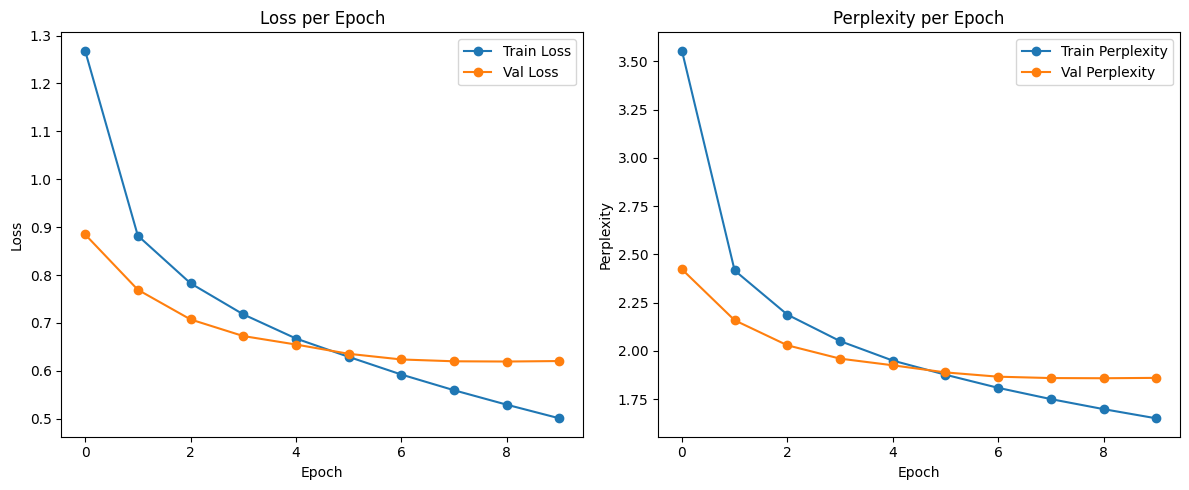

In [ ]:
# === Step 3.3: Training Loop with Validation ===

import torch
import math
import time
import matplotlib.pyplot as plt
from torch.utils.data import random_split, DataLoader
from torch.optim import AdamW

# === Step 1: Split Dataset (70% Train, 15% Val, 15% Test) ===
total_len = len(dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

# Randomly split the dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_len, val_len, test_len])

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2)

# === Step 2: Setup Optimizer and Variables for Tracking ===
optimizer = AdamW(model.parameters(), lr=5e-5)
num_epochs = 10  # Number of training epochs

# Lists to keep track of loss and perplexity per epoch
train_losses, val_losses = [], []
train_ppls, val_ppls = [], []

# === Step 3: Training Loop ===
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0  # Track total training loss
    start_time = time.time()  # Start time to measure epoch duration

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        image_feature = batch["image_feature"].to(device)

        # Prepare cross-attention input: [batch_size, 1, hidden_size]
        '''
        unsqueeze(1) reshapes image_feature from [batch_size, 768] → [batch_size, 1, 768]
        GPT-2 expects cross-attention input with shape [batch_size, sequence_length, hidden_size]
        '''
        encoder_hidden_states = image_feature.unsqueeze(1)

        # Forward pass through the model
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_hidden_states=encoder_hidden_states,
            labels=input_ids  # Target is same as input for language modeling,The target
                                #/label is the same sequence The input, but shifted
        )


        loss = outputs.loss

        # Backward pass and optimization step
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        torch.cuda.empty_cache()  # free up GPU memory

        total_train_loss += loss.item()  # Accumulate batch loss

    # Compute average train loss and perplexity for this epoch
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_ppls.append(math.exp(avg_train_loss))

    # === Step 4: Validation Loop ===
    model.eval()
    total_val_loss = 0  # Track total validation loss

    with torch.no_grad():  # No gradient computation during validation
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            image_feature = batch["image_feature"].to(device)

            encoder_hidden_states = image_feature.unsqueeze(1)

            # Forward pass through the model
            outputs = model(
                input_ids=input_ids, # input_ids are the token IDs of the text.
                attention_mask=attention_mask,
                encoder_hidden_states=encoder_hidden_states,
                labels=input_ids
            )

            total_val_loss += outputs.loss.item()

    # Compute average validation loss and perplexity for this epoch
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_ppls.append(math.exp(avg_val_loss))

    # === Log Results for the Current Epoch ===
    print(f"✅ Epoch {epoch+1}/{num_epochs}")
    print(f"   Train Loss: {avg_train_loss:.4f}, Perplexity: {math.exp(avg_train_loss):.2f}")
    print(f"   Val   Loss: {avg_val_loss:.4f}, Perplexity: {math.exp(avg_val_loss):.2f}")
    print(f"   Time: {int(time.time() - start_time)}s\n")

# === Step 5: Plot Training and Validation Loss and Perplexity ===
plt.figure(figsize=(12, 5))

# Plot Loss per Epoch
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Val Loss", marker='o')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot Perplexity per Epoch
plt.subplot(1, 2, 2)
plt.plot(train_ppls, label="Train Perplexity", marker='o')
plt.plot(val_ppls, label="Val Perplexity", marker='o')
plt.title("Perplexity per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# === Step 3.4: Inference — Generate Reports from Test Images ===

from transformers import GPT2Tokenizer
from torch.nn.functional import pad

# Set model to evaluation mode (disable dropout, fix layer norms)
model.eval()

results = []  # List to store results for all test images

# Loop over test dataset
for idx, sample in enumerate(test_dataset):
    # Prepare image features for cross-attention
    image_feature = sample["image_feature"].unsqueeze(0).to(device)  # add batch dimension — becomes [1, 768].
    encoder_hidden_states = image_feature.unsqueeze(1)  # add sequence length dimension(one image) — becomes [1, 1, 768]
                                                         #(what GPT-2 expects for cross-attention input).

    # Generate caption using the model
    generated = model.generate(
        input_ids=None,                          # Start from scratch (no text prompt), just condition on the image features.
        encoder_hidden_states=encoder_hidden_states,  # Image features for cross-attention
        max_length=70,                           # Maximum number of tokens to generate
        num_beams=3,                             # Beam search with 3 beams
        early_stopping=True,                     # Stop early if EOS is reached
        no_repeat_ngram_size=2,                  # Prevent repetition of 2-grams
        pad_token_id=tokenizer.pad_token_id      # f the sequence is shorter than max_length, as result of stop earlier, pad
    )

    # Decode generated token IDs into human-readable text.
    decoded_caption = tokenizer.decode(generated[0], skip_special_tokens=True) #skip_special_tokens=True
                                                                                #Removes padding, start/end tokens from the output.

    # Get ground-truth caption (remove padding tokens)
    true_caption = sample["input_ids"] #Take the input_ids (tokenized real caption).
    true_caption = true_caption[true_caption != tokenizer.pad_token_id] #Remove padded tokens (!= pad_token_id).
    reference = tokenizer.decode(true_caption, skip_special_tokens=True)#Decode the token IDs into readable text.

    # Save image path, reference caption, and generated caption
    results.append({
        "image_path": df.iloc[idx]["image_path"],        # Image path
        "reference_caption": df.iloc[idx]["caption"],    # Ground-truth caption from df
        "generated_caption": decoded_caption            # Model-generated caption
    })

# Save all results into a CSV file
results_df = pd.DataFrame(results)
results_df.to_csv("generated_reports.csv", index=False)
print("✅ Saved generated captions to 'generated_reports.csv'")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


✅ Saved generated captions to 'generated_reports.csv'


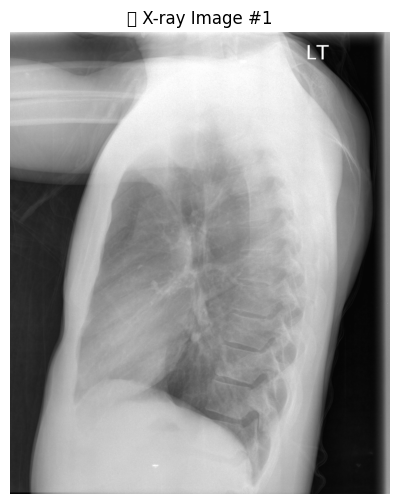

🟢 Ground Truth (Caption):
positive tb test. normal chest x. the cardiac silhouette and mediastinum size are within normal limits. there is no pulmonary edema. there is no focal consolidation. there are no of a pleural effusion. there is no evidence of pneumothorax.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax demonstrate healed remote bilateral lower thoracic vertebral bodies without



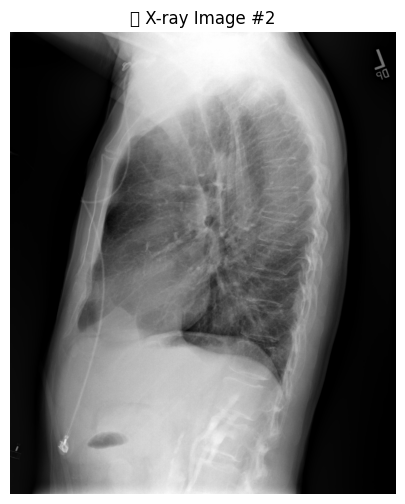

🟢 Ground Truth (Caption):
preop bariatric surgery. no acute pulmonary findings. borderline cardiomegaly. midline sternotomy. enlarged pulmonary arteries. clear lungs. inferior.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax demonstrate healed remote bilateral lower thoracic vertebral bodies without



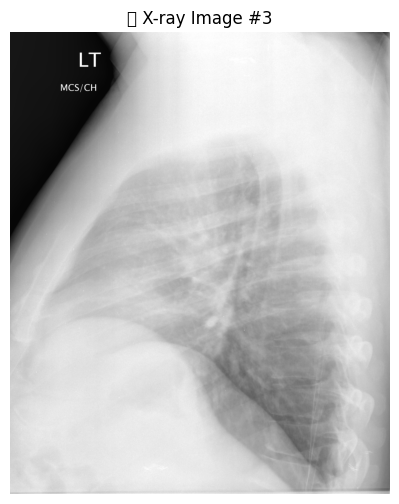

🟢 Ground Truth (Caption):
rib pain after a steps this. pain to r back r elbow and r rib no previous heart or lung hx non no hx ca. no displaced rib fractures pneumothorax or pleural effusion identified. well expanded and clear lungs. mediastinal contour within normal limits. no acute cardiopulmonary abnormality identified. no findings.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax demonstrate stable mild multilevel thoracolumbar degener



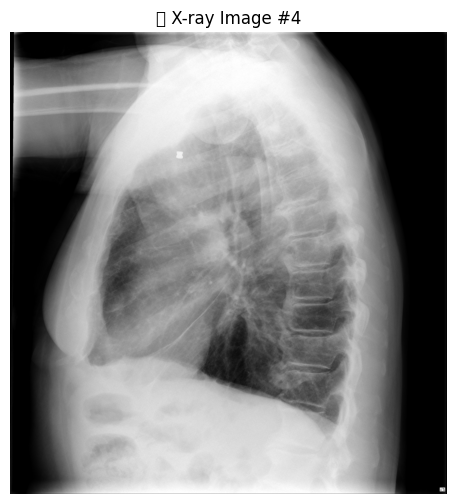

🟢 Ground Truth (Caption):
year old with. bullous emphysema and interstitial fibrosis. probably scarring in the left apex although difficult to exclude a cavitary lesion. opacities in the bilateral upper lobes could represent scarring however the absence of comparison exam recommend short interval followup radiograph or ct thorax to document resolution. there are diffuse bilateral interstitial and alveolar opacities consistent with chronic obstructive lung disease and bullous emphysema. there are irregular opacities in the left lung apex that could represent a cavitary lesion in the left lung apex. there are streaky opacities in the right upper lobe scarring. the cardiomediastinal silhouette is normal in size and contour. there is no pneumothorax or large pleural effusion.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio medias

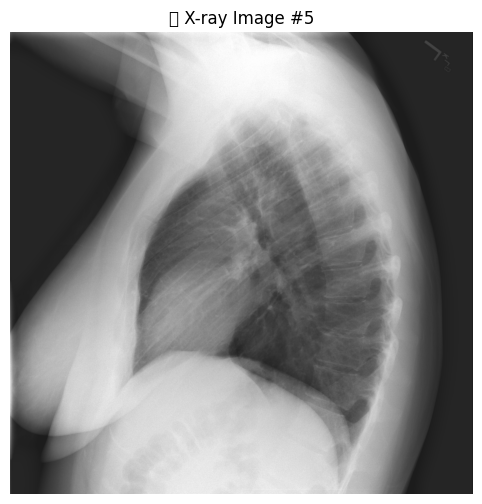

🟢 Ground Truth (Caption):
chest and nasal congestion. no acute cardiopulmonary abnormality. the cardiomediastinal silhouette and pulmonary vasculature are within normal limits. there is no pneumothorax or pleural effusion. there are no focal areas of consolidation. cholecystectomy clips are present. small t spine osteophytes. there is biapical pleural thickening unchanged from prior. mildly hyperexpanded lungs.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax demonstrate stable mild multilevel thoracolumbar degener



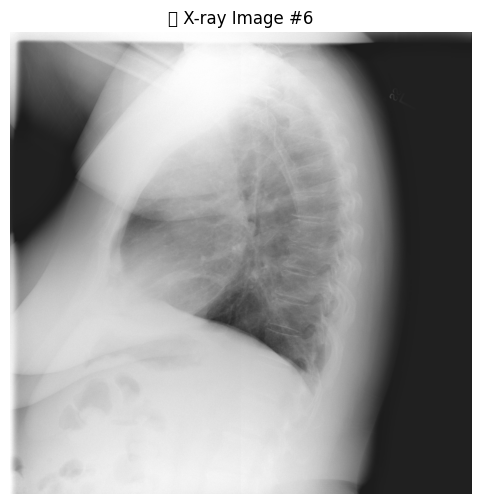

🟢 Ground Truth (Caption):
evaluate for infection. no acute cardiopulmonary findings. heart size and mediastinal contour are within normal limits. there is no focal airspace consolidation or suspicious pulmonary opacity. no pneumothorax or large pleural effusion. mild degenerative change of the thoracic spine.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax demonstrate stable mild multilevel thoracolumbar degener



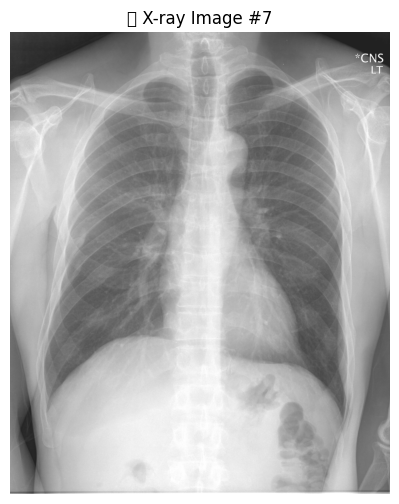

🟢 Ground Truth (Caption):
preop lumbar surgery. basilar atelectasis. no confluent lobar consolidation or pleural effusion. the cardiac contours are normal. the lungs are clear. thoracic spondylosis. lower cervical arthritis.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax demonstrate stable mild multilevel thoracolumbar degener



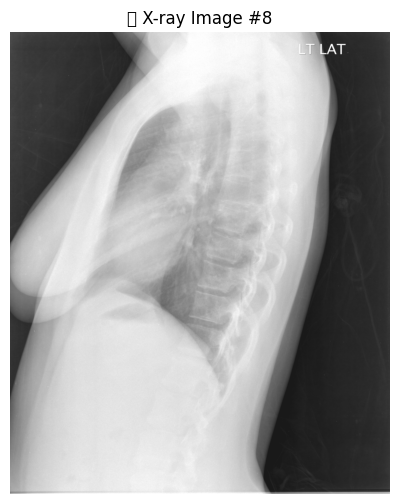

🟢 Ground Truth (Caption):
year old with on. dyspnea. history of mitral valve prolapse. no acute cardiopulmonary disease. the heart pulmonary and mediastinum are within normal limits. there is no pleural effusion or pneumothorax. there is no focal air space opacity to suggest a pneumonia. there is an interim cervical spinal fusion partly evaluated.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax demonstrate healed remote bilateral lower thoracic vertebral bodies without



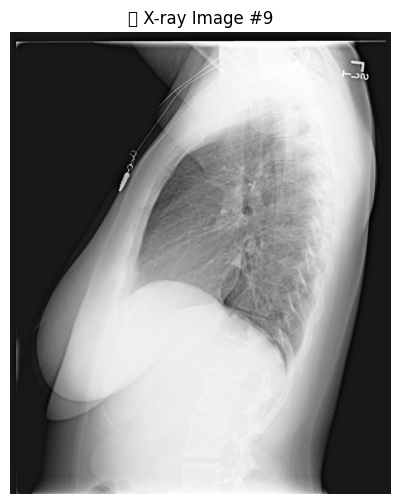

🟢 Ground Truth (Caption):
chest pain today. history of stent placement years ago. increased size of density in the left cardiophrenic. primary differential considerations include increased size of prominent epicardial fat pericardial mass pleural mass or cardiac aneurysm. ct chest with contrast is recommended. these findings and recommendations were discussed. by dr. telephone at p. m. dr. technologist receipt of the results. the examination consists of frontal and lateral radiographs of the chest. the cardiac silhouette is not enlarged. there has been apparent interval increase in low density convexity at the left cardiophrenic. calcified granuloma is again seen in the right upper lobe. there is no consolidation pleural effusion or pneumothorax.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unrema

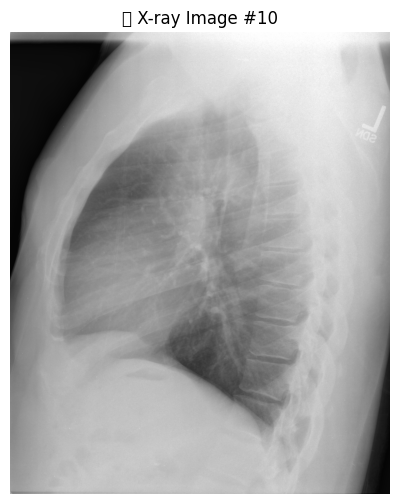

🟢 Ground Truth (Caption):
year old male chest pain. no acute cardiopulmonary process. the cardiomediastinal silhouette is within normal limits for size and contour. the lungs are normally inflated without evidence of focal airspace disease pleural effusion or pneumothorax. stable calcified granuloma within the right upper lung. no acute bone abnormality.

🔵 Generated Caption:
 old female with chest pain. no acute cardiopulmonary abnormality. the lungs are clear bilaterally. specifically no evidence of focal consolidation pneumothorax or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax demonstrate stable mild multilevel thoracolumbar degener



In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# Load the saved results
df = pd.read_csv("generated_reports.csv")

# Show the first 10 samples
for idx in range(min(10, len(df))):
    image_path = df.iloc[idx]["image_path"]
    img = Image.open(image_path).convert("RGB")

    # Show the image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"🩻 X-ray Image #{idx + 1}")
    plt.show()

    # Show the captions
    print(f"🟢 Ground Truth (Caption):\n{df.iloc[idx]['reference_caption']}\n")
    print(f"🔵 Generated Caption:\n{df.iloc[idx]['generated_caption']}\n")
    print("=" * 100)



# Step 4: Evaluation of Generated Reports

1. **Load Results**:
   - Read `generated_reports.csv` containing generated and reference captions.

2. **Preprocess Captions**:
   - Tokenize captions for BLEU evaluation.
   - No special preprocessing for ROUGE-L or BERTScore.

3. **BLEU Evaluation**:
   - Compute BLEU-1, BLEU-2, BLEU-3, and BLEU-4 using `nltk` with smoothing.

4. **ROUGE-L Evaluation**:
   - Compute ROUGE-L F1 score using `rouge_scorer`.

5. **BERTScore Evaluation**:
   - Compute semantic similarity using `bert-score` package.
   - Model: `distilbert-base-uncased`.
   - Output: F1 score.

📊 **Final Metrics**:
- BLEU-1, BLEU-2, BLEU-3, BLEU-4
- ROUGE-L
- BERTScore (F1)

✅ **Outcome**:
> Quantitative evaluation of generated medical reports using both n-gram and semantic similarity metrics.




In [ ]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b4bed05f5fbadb94f3ac812a701cc52ff44ca29ef18797bfc2c3254f2f2a0233
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


In [ ]:
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.4 MB/s eta 0:00:00


In [ ]:
# === Step 4: Evaluation of Generated Reports ===

import pandas as pd
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bertscore
import nltk

# Download required NLTK resources for METEOR
nltk.download('wordnet')
nltk.download('omw-1.4')

# === Load Generated Captions and Reference Captions ===
results_df = pd.read_csv("generated_reports.csv")
generated_captions = results_df["generated_caption"].tolist()
reference_captions = results_df["reference_caption"].tolist()

# === Step 1: Preprocess for BLEU Evaluation ===
tokenized_preds = [pred.split() for pred in generated_captions]
tokenized_refs = [[ref.split()] for ref in reference_captions]  # nested list for corpus_bleu
smoothie = SmoothingFunction().method4  # smoothing for short sentences

# BLEU Scoring
bleu_1 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(1, 0, 0, 0), smoothing_function=smoothie)
bleu_2 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
bleu_3 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
bleu_4 = corpus_bleu(tokenized_refs, tokenized_preds, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

# === Step 2: ROUGE-L Evaluation ===
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l_scores = [scorer.score(ref, pred)['rougeL'].fmeasure for ref, pred in zip(reference_captions, generated_captions)]
rouge_l = sum(rouge_l_scores) / len(rouge_l_scores)

# === Step 3: METEOR Evaluation ===
# === Step 3: METEOR Evaluation ===
meteor_scores = [
    meteor_score([ref.split()], pred.split())
    for ref, pred in zip(reference_captions, generated_captions)
]
meteor_avg = sum(meteor_scores) / len(meteor_scores)


# === Step 4: BERTScore Evaluation ===
P, R, F1 = bertscore(
    generated_captions,
    reference_captions,
    model_type="distilbert-base-uncased",
    lang='en',
    rescale_with_baseline=True,
    batch_size=4,
    device='cpu'

)
bertscore_f1 = F1.mean().item()

# === Final Result Printout ===
print("\n📊 Final Evaluation Results:")
print(f"BLEU-1: {bleu_1:.4f}")
print(f"BLEU-2: {bleu_2:.4f}")
print(f"BLEU-3: {bleu_3:.4f}")
print(f"BLEU-4: {bleu_4:.4f}")
print(f"ROUGE-L: {rouge_l:.4f}")
print(f"METEOR: {meteor_avg:.4f}")
print(f"BERTScore (F1): {bertscore_f1:.4f}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


📊 Final Evaluation Results:
BLEU-1: 0.3007
BLEU-2: 0.1848
BLEU-3: 0.1277
BLEU-4: 0.0878
ROUGE-L: 0.2644
METEOR: 0.2504
BERTScore (F1): 0.5560
